In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk 
from sklearn.model_selection import train_test_split as TTS
from sklearn.metrics import mean_squared_error as MSE, r2_score as R2

In [4]:
df = pd.read_csv( "SOCR-HeightWeight.csv") 
df.head(5)


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [5]:
df = df.loc[ :3000, ["Height(Inches)" , "Weight(Pounds)"] ] 

In [6]:
df.isna().sum() 

Height(Inches)    0
Weight(Pounds)    0
dtype: int64

In [7]:
df.shape

(3001, 2)

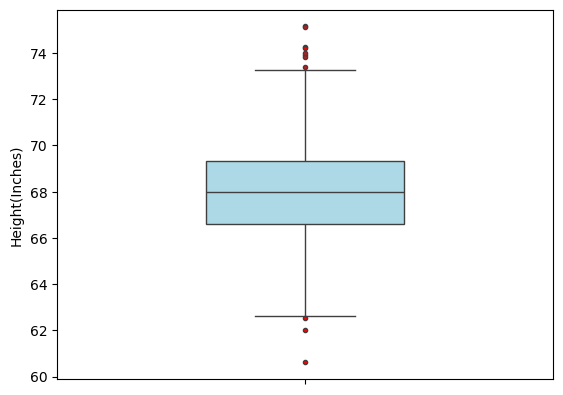

In [8]:
import seaborn as sns

plt.figure( )

sns.boxplot(data=  df.iloc[:,0],  width = 0.4 , 
            boxprops=dict(facecolor='lightblue'), 
            flierprops=dict(marker='o', 
                            markerfacecolor='red',
                            markersize=3),
           )


plt.show() 

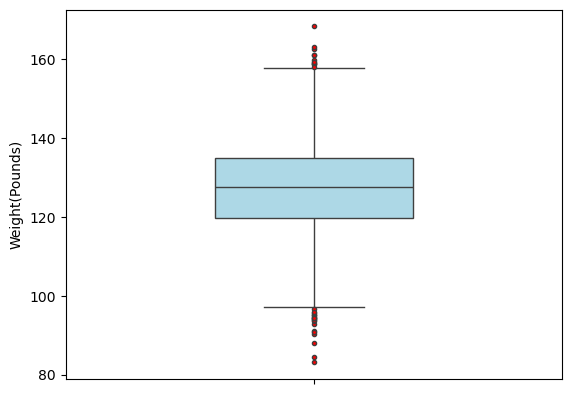

In [9]:
plt.figure( )
sns.boxplot(data=  df.iloc[:,1],  width = 0.4 , 
            boxprops=dict(facecolor='lightblue'), 
            flierprops=dict(marker='o', 
                            markerfacecolor='red',
                            markersize=3),
        )

plt.show() 

In [10]:
df.describe() 

,Height(Inches),Weight(Pounds)
count,3001.000000,3001.000000
mean,68.002732,127.294928
std,1.940371,11.579323
min,60.612650,83.085270
25%,66.611290,119.767100
50%,67.998310,127.471800
75%,69.309570,134.991700
max,75.152800,168.229000


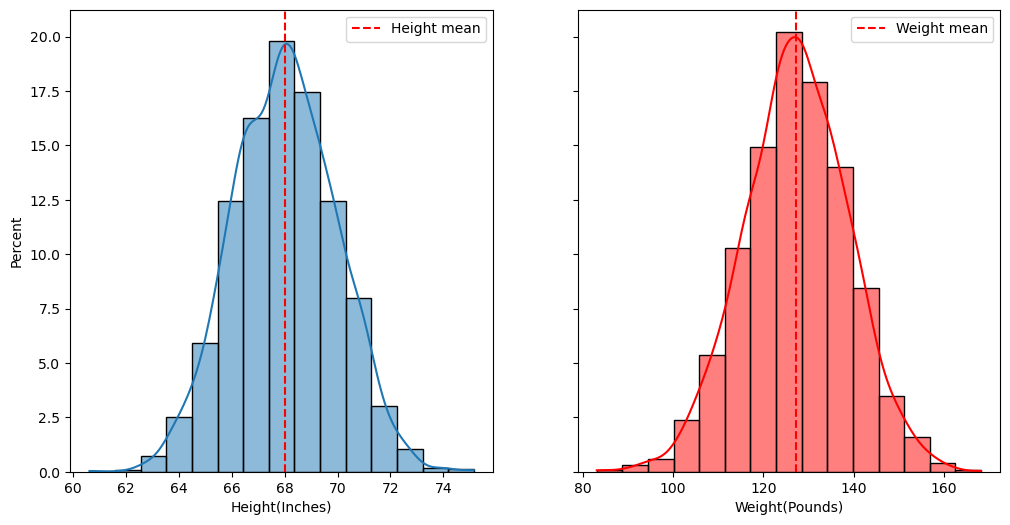

In [11]:
fig, ax = plt.subplots( 1,2 , figsize =(12,6), sharex = False , sharey = True) 

sns.histplot( data =  df.iloc[:,0] , bins = 15, stat= 'percent', kde = True , ax = ax[0])
ax[0].axvline(df.iloc[:, 0].mean(), color='red', linestyle='--', label ='Height mean')
ax[0].legend() 

sns.histplot( data =  df.iloc[:,1] , bins = 15, stat= 'percent', kde = True , ax = ax[1], color = 'red')
ax[1].axvline(df.iloc[:, 1].mean(), color='red', linestyle='--', label ='Weight mean')
ax[1].legend() 

plt.show( )

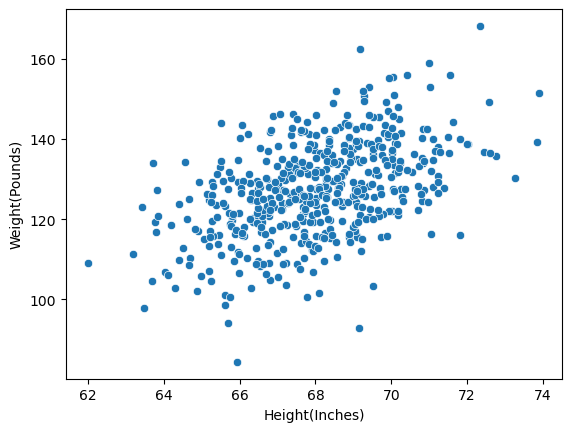

In [12]:
plt.figure() 

sns.scatterplot( data = df , x = df['Height(Inches)'][:500] , y =df['Weight(Pounds)'][:500]) 

plt.show( ) 

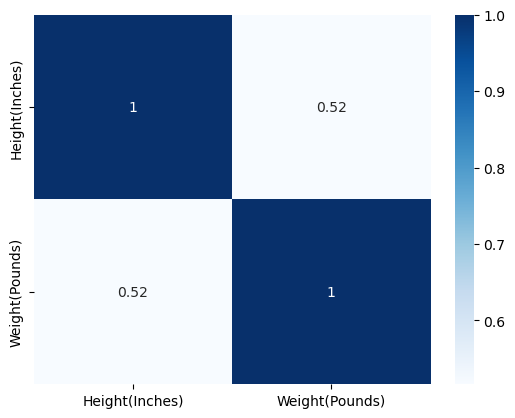

In [13]:
corr = df.corr() 
plt.figure( )
sns.heatmap ( corr , annot=True ,cmap ='Blues') 
plt.show( )

In [14]:
import pandas as pd

df['Height_Group'] = pd.cut(df['Height(Inches)'], bins=[60, 65, 70, 75], labels=['Short', 'Average', 'Tall'])

df['Weight_Group'] = pd.cut(df['Weight(Pounds)'], bins=[100, 130, 160, 190], labels=['Light', 'Medium', 'Heavy'])

cross = pd.crosstab(df['Height_Group'], df['Weight_Group'], normalize=True)
cross


Weight_Group,Light,Medium,Heavy
Height_Group,,,
Short,0.049158,0.004040,0.000000
Average,0.500000,0.285185,0.000673
Tall,0.045118,0.114815,0.001010


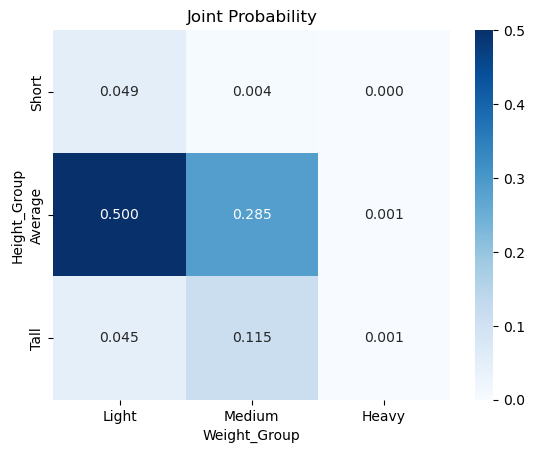

In [15]:
plt.figure() 

sns.heatmap ( cross , cmap = 'Blues',annot= True, linecolor = 'black' ,fmt ='.3f' ) 
plt.title( 'Joint Probability') 
plt.show( )

In [16]:
pd.cut(df['Height(Inches)'], bins=[60, 65, 70, 75], labels=['Short', 'Average', 'Tall']).value_counts()

Height(Inches)
Average    2347
Tall        478
Short       174
Name: count, dtype: int64

In [17]:
df['BMI'] = 703 * (df['Weight(Pounds)'] / (df['Height(Inches)'] ** 2))
df.sample(5)

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI
1674,69.28403,109.2101,Average,Light,15.993807
2092,64.65639,106.5790,Short,Light,17.922726
2798,66.78698,104.0527,Average,Light,16.399291
706,68.18868,111.4951,Average,Light,16.857243
1518,70.97634,121.2170,Tall,Light,16.915765


In [18]:
df['BMI_Class'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df.sample(20)

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI,BMI_Class
733,64.96937,95.70426,Short,NaN,15.939301,Underweight
833,67.44291,123.08040,Average,Light,19.022677,Normal
2230,65.33382,129.76220,Average,Light,21.371127,Normal
127,67.92809,119.30870,Average,Light,18.177269,Underweight
13,67.11656,122.46180,Average,Light,19.111580,Normal
2057,67.28745,112.11970,Average,Light,17.408811,Underweight
1986,63.99095,123.66230,Short,Light,21.230271,Normal
2466,70.26356,154.94080,Tall,Medium,22.062810,Normal
2862,68.26193,117.90400,Average,Light,17.787984,Underweight
231,68.02363,141.10260,Average,Medium,21.437332,Normal


In [19]:
df['BMI_Class'].value_counts() 

BMI_Class
Normal         2150
Underweight     851
Overweight        0
Obese             0
Name: count, dtype: int64

In [20]:
df[df["BMI_Class"] == 'Overweight']

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI,BMI_Class


In [21]:
model = sk.linear_model.LinearRegression() 

X = df[['Height(Inches)']]   


y = df['Weight(Pounds)']     

model.fit( X, y ) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_hat = model.predict(X) 
df['Model Prediction'] = y_hat
df.head() 

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI,BMI_Class,Model Prediction
0,65.78331,112.9925,Average,Light,18.355808,Underweight,120.455677
1,71.51521,136.4873,Tall,Medium,18.760773,Normal,138.118793
2,69.39874,153.0269,Average,Medium,22.336747,Normal,131.596792
3,68.21660,142.3354,Average,Medium,21.502458,Normal,127.953973
4,67.78781,144.2971,Average,Medium,22.075458,Normal,126.632637


In [23]:
model.coef_ #Slope

array([3.0815463])

In [24]:
model.intercept_

np.float64(-82.2586381106455)

In [25]:
MSE( y , model.predict(X) ) 

98.29540870710602

In [26]:
R2( y , model.predict(X) ) 

0.26664938624722856

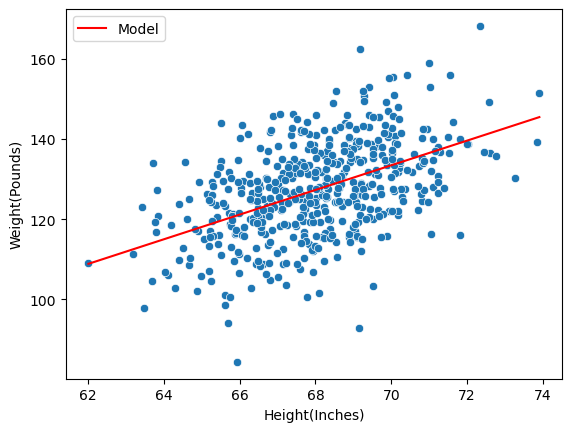

In [27]:
plt.figure() 
idx = np.random.permutation(500)
sns.scatterplot( data = df , x = df['Height(Inches)'][idx] , y =df['Weight(Pounds)'][idx])

sns.lineplot (data = df,  x = df['Height(Inches)'][idx] , y =df['Model Prediction'][idx] , color = 'red', label = 'Model') 
plt.legend() 
plt.show( ) 

(2250, 1) (751, 1) (2250,) (751,)


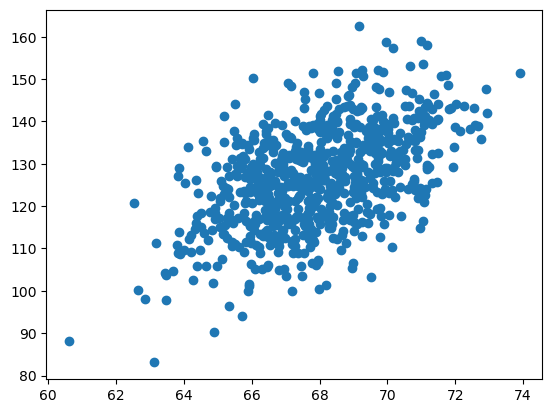

In [37]:
#Now training the lestt data

X_train , X_test, y_train , y_test = TTS(X,y, test_size = 0.25 , random_state=0 , shuffle= True ) 
print( X_train.shape , X_test.shape, y_train.shape , y_test.shape) 
plt.figure() 
plt.scatter( X_test , y_test) 
plt.show( )

In [66]:
#Train the model on the traning set

model.fit(X_train , y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
model.coef_  , model.intercept_

(array([3.09031207]), np.float64(-82.76857907082304))

In [68]:
MSE(y_train, model.predict(X_train) ) 

98.0649275660238

In [69]:
R2( y_train , model.predict(X_train) ) 

0.2663445426203278

In [70]:

model.fit( X_test , y_test) 



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
model.coef_  , model.intercept_

(array([3.05045585]), np.float64(-80.40509977363874))

In [71]:
MSE(y_test, model.predict(X_test) ) 

98.89208044489807

In [72]:
R2( y_test , model.predict(X_test) ) 

0.2667308309035725

In [80]:
#without shuffling , the shuffling is necesarry 
X_train , X_test, y_train , y_test = TTS(X,y, test_size = 0.25 , random_state=3 , shuffle= False ) 

model.fit( X_train , y_train) 


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
model.coef_ , model.intercept_ 

(array([2.98582351]), np.float64(-75.62489313445104))

In [82]:
R2( X_train , model.predict(X_train)) 

-937.1591141059109

Without shuffling the model failed